## Imports

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import albumentations as A

from shared.mat_reader import MatReader
from shared.constants import CLASS_NAMES
from shared.utils import robust_minmax

## Instantiation

In [5]:
# mat_reader = MatReader("/Users/james/GitHub/lampe/lampe_dataset/3x3 bad SHG removed/")
mat_reader = MatReader("/Users/james/GitHub/lampe/lampe_dataset/Full images/")

print(f"MatReader shape: {mat_reader.images.shape}")

unique_rows, counts = np.unique(mat_reader.class_labels, axis=0, return_counts=True)

total_count = 0
for unique_row, count in zip(unique_rows, counts):
    print(f"{CLASS_NAMES[unique_row]}: [{total_count} - {total_count + count - 1}]")
    total_count += count

idx = 100

img = robust_minmax(mat_reader.images[idx].transpose([1, 2, 0]), p_min=5.0, p_max=99.5)

MatReader shape: (104, 3, 512, 512)
LGC: [0 - 33]
IDC: [34 - 103]


# Augmentation

In [17]:
# Define the elastic transformation
# Alpha (α): Controls the intensity or magnitude of the displacement. A higher alpha means a more severe warp.
# Sigma (σ): Controls the smoothness of the displacement grid.
# A higher sigma means the warp is applied over larger, smoother regions (like a gentle wave),
# while a lower sigma creates tight, jagged distortions (which you want to avoid).

transform = A.Compose([
    A.ElasticTransform(
        alpha=100,      
        sigma=100 * 0.06, 
        alpha_affine=100 * 0.03, 
        border_mode=cv2.BORDER_REFLECT_101,
        p=1.0           
    )
])

# Pass your multi-modal array into the pipeline
aug_img = transform(image=img)['image']

/var/folders/w8/gkdw54n95gz2lyzfs2239r880000gn/T/ipykernel_27831/2967322000.py:8: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(


## Plots

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

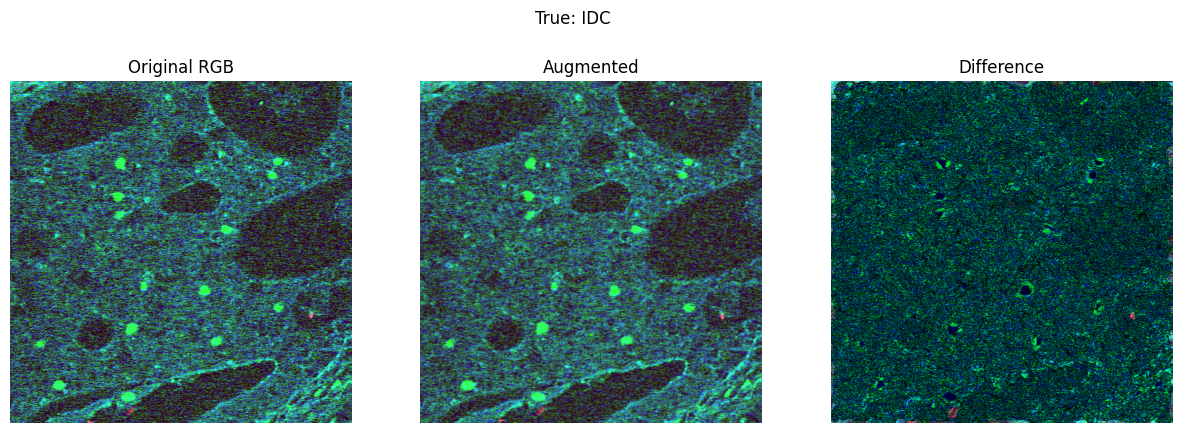

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

true_class = f"True: {CLASS_NAMES[mat_reader.class_labels[idx]]}"
fig.suptitle(true_class)

ax[0].imshow(img)
ax[0].set_title('Original RGB')
ax[0].axis('off')

ax[1].imshow(aug_img)
ax[1].set_title('Augmented')
ax[1].axis('off')

import cv2

diff_img = robust_minmax(cv2.absdiff(img, augmented_img), p_min=5.0, p_max=99.9)
ax[2].imshow(diff_img)
ax[2].set_title('Difference')
ax[2].axis('off')